In [3]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [117]:
ruta_archivo = "RepGeneralVen.xlsx"
df = pd.read_excel(ruta_archivo,header=5)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [47]:
pd.set_option('display.max_columns', None)


In [119]:
df.head(5)

,Documento,Unnamed: 1,Unnamed: 2,Fecha,Unnamed: 4,Folio,Unnamed: 6,Cliente,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Caja,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Usuario,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Folio F.,Unnamed: 24,Unnamed: 25,Est,Unnamed: 27,Unnamed: 28,Unnamed: 29,Total,Unnamed: 31,Efectivo,Cheque,Crédito,Transferencia,Vales,Tarjeta,Anticipo,SICAR Pagos
0,Ticket,NaN,NaN,2021-04-05 17:51:01,NaN,1.0,NaN,Público en General,NaN,NaN,NaN,NaN,Caja 1,NaN,NaN,NaN,NaN,admin,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,V,NaN,NaN,NaN,$ 0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PZA,1.0,NaN,NaT,"[ARTRAP1] prueba impresion tickets,",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,$ 0.00,NaN,NaN,NaT,NaN,NaN,NaN,NaN,$ 0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Ticket,NaN,NaN,2022-07-27 15:28:08,NaN,2.0,NaN,Público en General,NaN,NaN,NaN,NaN,Caja 1,NaN,NaN,NaN,NaN,admin,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,X,NaN,NaN,NaN,$ 20.00,NaN,$ 20.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00
3,PZA,1.0,NaN,NaT,"[12500] Cinta de aislar de 18 m x 19 mm, negra...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,$ 20.00,NaN,NaN,NaT,NaN,NaN,NaN,NaN,$ 20.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Ticket,NaN,NaN,2022-07-27 15:48:56,NaN,3.0,NaN,INSUMOS DISTRIBUIDORA SAN PEDRO,NaN,NaN,NaN,NaN,Caja 1,NaN,NaN,NaN,NaN,admin,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,X,NaN,NaN,NaN,"$ 1,060.00",NaN,"$ 1,060.00",$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00


In [120]:
df.tail(21)

,Documento,Unnamed: 1,Unnamed: 2,Fecha,Unnamed: 4,Folio,Unnamed: 6,Cliente,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Caja,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Usuario,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Folio F.,Unnamed: 24,Unnamed: 25,Est,Unnamed: 27,Unnamed: 28,Unnamed: 29,Total,Unnamed: 31,Efectivo,Cheque,Crédito,Transferencia,Vales,Tarjeta,Anticipo,SICAR Pagos
150408,Ticket,NaN,NaN,2026-05-16 18:04:33,NaN,49725.0,NaN,Público en General,NaN,NaN,NaN,NaN,Caja 1,NaN,NaN,NaN,NaN,admin,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,V,NaN,NaN,NaN,$ 31.00,NaN,$ 31.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00
150409,PZA,1.0,NaN,NaT,[14991] ACES-2 Aceite sintético para motor de ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,$ 31.00,NaN,NaN,NaT,NaN,NaN,NaN,NaN,$ 31.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150410,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150411,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Total Venta:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"$ 51,916,719.05",NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150412,Notas de Crédito,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150413,Notas de Crédito,NaN,NaN,2023-05-05 14:40:13,NaN,1.0,NaN,MIGUEL LOPEZ CAMPOS,NaN,NaN,NaN,NaN,Caja 1,NaN,NaN,NaN,NaN,admin,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,V,NaN,NaN,NaN,$ 240.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150414,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150415,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,Total Notas de Crédito:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,$ 240.00,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150416,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Totales por Forma de Pago,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150417,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Efectivo,NaN,NaT,NaN,NaN,NaN,NaN,"$ 48,266,325.29",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [121]:
df_master = df.iloc[:-19].copy()

In [122]:
df_master.head(10)

,Documento,Unnamed: 1,Unnamed: 2,Fecha,Unnamed: 4,Folio,Unnamed: 6,Cliente,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Caja,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Usuario,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Folio F.,Unnamed: 24,Unnamed: 25,Est,Unnamed: 27,Unnamed: 28,Unnamed: 29,Total,Unnamed: 31,Efectivo,Cheque,Crédito,Transferencia,Vales,Tarjeta,Anticipo,SICAR Pagos
0,Ticket,NaN,NaN,2021-04-05 17:51:01,NaN,1.0,NaN,Público en General,NaN,NaN,NaN,NaN,Caja 1,NaN,NaN,NaN,NaN,admin,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,V,NaN,NaN,NaN,$ 0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PZA,1.0,NaN,NaT,"[ARTRAP1] prueba impresion tickets,",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,$ 0.00,NaN,NaN,NaT,NaN,NaN,NaN,NaN,$ 0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Ticket,NaN,NaN,2022-07-27 15:28:08,NaN,2.0,NaN,Público en General,NaN,NaN,NaN,NaN,Caja 1,NaN,NaN,NaN,NaN,admin,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,X,NaN,NaN,NaN,$ 20.00,NaN,$ 20.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00
3,PZA,1.0,NaN,NaT,"[12500] Cinta de aislar de 18 m x 19 mm, negra...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,$ 20.00,NaN,NaN,NaT,NaN,NaN,NaN,NaN,$ 20.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Ticket,NaN,NaN,2022-07-27 15:48:56,NaN,3.0,NaN,INSUMOS DISTRIBUIDORA SAN PEDRO,NaN,NaN,NaN,NaN,Caja 1,NaN,NaN,NaN,NaN,admin,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,X,NaN,NaN,NaN,"$ 1,060.00",NaN,"$ 1,060.00",$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00
5,BULTO,5.0,NaN,NaT,[0054] CEMENTO GRIS CRUZ AZUL CPC 30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,$ 212.00,NaN,NaN,NaT,NaN,NaN,NaN,NaN,"$ 1,060.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Ticket,NaN,NaN,2022-07-27 15:55:34,NaN,3.0,NaN,INSUMOS DISTRIBUIDORA SAN PEDRO,NaN,NaN,NaN,NaN,Caja 1,NaN,NaN,NaN,NaN,admin,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,X,NaN,NaN,NaN,"-$ 1,060.00",NaN,"$ 1,060.00",$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00
7,BULTO,5.0,NaN,NaT,[0054] CEMENTO GRIS CRUZ AZUL CPC 30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,$ 212.00,NaN,NaN,NaT,NaN,NaN,NaN,NaN,"$ 1,060.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Ticket,NaN,NaN,2022-07-27 15:56:38,NaN,2.0,NaN,Público en General,NaN,NaN,NaN,NaN,Caja 1,NaN,NaN,NaN,NaN,admin,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,X,NaN,NaN,NaN,-$ 20.00,NaN,$ 20.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00
9,PZA,1.0,NaN,NaT,"[12500] Cinta de aislar de 18 m x 19 mm, negra...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,$ 20.00,NaN,NaN,NaT,NaN,NaN,NaN,NaN,$ 20.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [123]:
#SE QUITARON FILAS INICIALES Y FINALES DEL DATAFRAME QUE SON BASURA DE SICAR

In [135]:
df_master['Folio_Clean'] = df_master['Folio'].astype(str).str.strip().str.replace('.0', '', regex=False)


In [125]:
columnas_vacias = df_master.columns[df_master.isna().all()].tolist()

In [126]:
print(f"Se encontraron {len(columnas_vacias)} columnas completamente vacías.")
if columnas_vacias:
    print("Columnas detectadas para eliminación:", columnas_vacias)
else:
    print("No hay columnas puras de NaN en este DataFrame.")

Se encontraron 20 columnas completamente vacías.
Columnas detectadas para eliminación: ['Unnamed: 2', 'Unnamed: 6', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 18', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Folio F.', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 31']


In [127]:
df_master= df.drop(columns=columnas_vacias)
print(f"¡Limpieza exitosa!")

¡Limpieza exitosa!


In [136]:
df_master.head(10)

,Documento,Unnamed: 1,Fecha,Unnamed: 4,Folio,Cliente,Caja,Usuario,Unnamed: 19,Est,Unnamed: 27,Total,Efectivo,Cheque,Crédito,Transferencia,Vales,Tarjeta,Anticipo,SICAR Pagos,tipo_documento,unidad,Folio_Clean
0,Ticket,NaN,2021-04-05 17:51:01,NaN,1.0,Público en General,Caja 1,admin,NaN,V,NaN,$ 0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ticket,NaN,1
1,PZA,1.0,NaT,"[ARTRAP1] prueba impresion tickets,",1.0,NaN,NaN,NaN,$ 0.00,NaN,$ 0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PZA,1
2,Ticket,NaN,2022-07-27 15:28:08,NaN,2.0,Público en General,Caja 1,admin,NaN,X,NaN,$ 20.00,$ 20.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,Ticket,NaN,2
3,PZA,1.0,NaT,"[12500] Cinta de aislar de 18 m x 19 mm, negra...",2.0,NaN,NaN,NaN,$ 20.00,NaN,$ 20.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PZA,2
4,Ticket,NaN,2022-07-27 15:48:56,NaN,3.0,INSUMOS DISTRIBUIDORA SAN PEDRO,Caja 1,admin,NaN,X,NaN,"$ 1,060.00","$ 1,060.00",$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,Ticket,NaN,3
5,BULTO,5.0,NaT,[0054] CEMENTO GRIS CRUZ AZUL CPC 30,3.0,NaN,NaN,NaN,$ 212.00,NaN,"$ 1,060.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BULTO,3
6,Ticket,NaN,2022-07-27 15:55:34,NaN,3.0,INSUMOS DISTRIBUIDORA SAN PEDRO,Caja 1,admin,NaN,X,NaN,"-$ 1,060.00","$ 1,060.00",$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,Ticket,NaN,3
7,BULTO,5.0,NaT,[0054] CEMENTO GRIS CRUZ AZUL CPC 30,3.0,NaN,NaN,NaN,$ 212.00,NaN,"$ 1,060.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BULTO,3
8,Ticket,NaN,2022-07-27 15:56:38,NaN,2.0,Público en General,Caja 1,admin,NaN,X,NaN,-$ 20.00,$ 20.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,Ticket,NaN,2
9,PZA,1.0,NaT,"[12500] Cinta de aislar de 18 m x 19 mm, negra...",2.0,NaN,NaN,NaN,$ 20.00,NaN,$ 20.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PZA,2


In [137]:
df_master['Folio'] = df_master['Folio'].astype(str).str.strip().replace(r'^\s*$', np.nan, regex=True)

In [138]:
documentos_maestros = ['Ticket', 'Notas de Crédito', 'Remisión', 'Nota de Venta']
unidades_maestras = ['PZA', 'BULTO', 'KG', 'SET', 'm', 'CAJA', 'METRO', 'PAR', 'ROLLO', 'BOLSA', 'JUEGO']

In [139]:
df_master['tipo_documento'] = df_master['Documento'].where(df['Documento'].isin(documentos_maestros))
df_master['unidad'] = df_master['Documento'].where(df['Documento'].isin(unidades_maestras))


In [140]:
df_master.head(10)

,Documento,Unnamed: 1,Fecha,Unnamed: 4,Folio,Cliente,Caja,Usuario,Unnamed: 19,Est,Unnamed: 27,Total,Efectivo,Cheque,Crédito,Transferencia,Vales,Tarjeta,Anticipo,SICAR Pagos,tipo_documento,unidad,Folio_Clean
0,Ticket,NaN,2021-04-05 17:51:01,NaN,1.0,Público en General,Caja 1,admin,NaN,V,NaN,$ 0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ticket,NaN,1
1,PZA,1.0,NaT,"[ARTRAP1] prueba impresion tickets,",1.0,NaN,NaN,NaN,$ 0.00,NaN,$ 0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PZA,1
2,Ticket,NaN,2022-07-27 15:28:08,NaN,2.0,Público en General,Caja 1,admin,NaN,X,NaN,$ 20.00,$ 20.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,Ticket,NaN,2
3,PZA,1.0,NaT,"[12500] Cinta de aislar de 18 m x 19 mm, negra...",2.0,NaN,NaN,NaN,$ 20.00,NaN,$ 20.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PZA,2
4,Ticket,NaN,2022-07-27 15:48:56,NaN,3.0,INSUMOS DISTRIBUIDORA SAN PEDRO,Caja 1,admin,NaN,X,NaN,"$ 1,060.00","$ 1,060.00",$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,Ticket,NaN,3
5,BULTO,5.0,NaT,[0054] CEMENTO GRIS CRUZ AZUL CPC 30,3.0,NaN,NaN,NaN,$ 212.00,NaN,"$ 1,060.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BULTO,3
6,Ticket,NaN,2022-07-27 15:55:34,NaN,3.0,INSUMOS DISTRIBUIDORA SAN PEDRO,Caja 1,admin,NaN,X,NaN,"-$ 1,060.00","$ 1,060.00",$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,Ticket,NaN,3
7,BULTO,5.0,NaT,[0054] CEMENTO GRIS CRUZ AZUL CPC 30,3.0,NaN,NaN,NaN,$ 212.00,NaN,"$ 1,060.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BULTO,3
8,Ticket,NaN,2022-07-27 15:56:38,NaN,2.0,Público en General,Caja 1,admin,NaN,X,NaN,-$ 20.00,$ 20.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,Ticket,NaN,2
9,PZA,1.0,NaT,"[12500] Cinta de aislar de 18 m x 19 mm, negra...",2.0,NaN,NaN,NaN,$ 20.00,NaN,$ 20.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PZA,2


In [141]:
df_master['Folio'] = df_master['Folio'].ffill()
df_master['Folio_Clean'] = df_master['Folio_Clean'].ffill()

In [142]:
columnas_contexto_seguro = ['tipo_documento', 'Caja', 'Fecha', 'Est', 'Cliente', 'Usuario']
df_master[columnas_contexto_seguro] = df_master.groupby('Folio')[columnas_contexto_seguro].ffill()

In [143]:
df_master = df_master.drop(columns=['Documento'])

In [144]:
df_master = df_master.rename(columns={'Unnamed: 1': 'cantidad'})

In [145]:
df_master = df_master.rename(columns={'Unnamed: 4': 'descripcion_clave'})

In [146]:
df_master = df_master.rename(columns={'Unnamed: 19': 'precio por unidad'})

In [147]:
df_master = df_master.rename(columns={'Unnamed: 27': 'subtotal'})

In [148]:
df_master.columns = df_master.columns.str.strip()

In [149]:
columnas_cabecera = ['Cliente', 'Fecha', 'Caja','Total','Efectivo','Usuario','Cheque','Crédito','Transferencia','Vales','Tarjeta','Anticipo','SICAR Pagos', 'tipo_documento', 'Est']
df_master['Folio'] = df_master['Folio'].ffill()
df_master[columnas_cabecera] = df_master.groupby('Folio')[columnas_cabecera].ffill()

In [150]:
filas_antes = len(df_master)
df_master = df_master.dropna(subset=['descripcion_clave']).reset_index(drop=True)
filas_eliminadas = filas_antes - len(df_master)
print(f"Filas originales: {filas_antes}")
print(f"Filas de cabecera eliminadas con éxito: {filas_eliminadas}")
print(f"Registros de productos listos para el EDA: {len(df_master)}")

Filas originales: 150429
Filas de cabecera eliminadas con éxito: 50889
Registros de productos listos para el EDA: 99540


In [151]:
df_master = df_master.iloc[1:].reset_index(drop=True) # se elimina primer fila por ser de pruebas

In [152]:
df_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 99539 entries, 0 to 99538
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   cantidad           99538 non-null  float64       
 1   Fecha              99539 non-null  datetime64[us]
 2   descripcion_clave  99539 non-null  str           
 3   Folio              99539 non-null  str           
 4   Cliente            99539 non-null  str           
 5   Caja               99539 non-null  str           
 6   Usuario            99539 non-null  str           
 7   precio por unidad  99538 non-null  str           
 8   Est                99539 non-null  str           
 9   subtotal           99538 non-null  str           
 10  Total              99539 non-null  str           
 11  Efectivo           99539 non-null  str           
 12  Cheque             99539 non-null  str           
 13  Crédito            99539 non-null  str           
 14  Transferencia    

In [153]:
df_master.columns = df_master.columns.str.strip().str.lower().str.replace(' ', '_')

In [154]:
df.head(10)

,Documento,Unnamed: 1,Unnamed: 2,Fecha,Unnamed: 4,Folio,Unnamed: 6,Cliente,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Caja,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Usuario,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Folio F.,Unnamed: 24,Unnamed: 25,Est,Unnamed: 27,Unnamed: 28,Unnamed: 29,Total,Unnamed: 31,Efectivo,Cheque,Crédito,Transferencia,Vales,Tarjeta,Anticipo,SICAR Pagos
0,Ticket,NaN,NaN,2021-04-05 17:51:01,NaN,1.0,NaN,Público en General,NaN,NaN,NaN,NaN,Caja 1,NaN,NaN,NaN,NaN,admin,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,V,NaN,NaN,NaN,$ 0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PZA,1.0,NaN,NaT,"[ARTRAP1] prueba impresion tickets,",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,$ 0.00,NaN,NaN,NaT,NaN,NaN,NaN,NaN,$ 0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Ticket,NaN,NaN,2022-07-27 15:28:08,NaN,2.0,NaN,Público en General,NaN,NaN,NaN,NaN,Caja 1,NaN,NaN,NaN,NaN,admin,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,X,NaN,NaN,NaN,$ 20.00,NaN,$ 20.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00
3,PZA,1.0,NaN,NaT,"[12500] Cinta de aislar de 18 m x 19 mm, negra...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,$ 20.00,NaN,NaN,NaT,NaN,NaN,NaN,NaN,$ 20.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Ticket,NaN,NaN,2022-07-27 15:48:56,NaN,3.0,NaN,INSUMOS DISTRIBUIDORA SAN PEDRO,NaN,NaN,NaN,NaN,Caja 1,NaN,NaN,NaN,NaN,admin,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,X,NaN,NaN,NaN,"$ 1,060.00",NaN,"$ 1,060.00",$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00
5,BULTO,5.0,NaN,NaT,[0054] CEMENTO GRIS CRUZ AZUL CPC 30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,$ 212.00,NaN,NaN,NaT,NaN,NaN,NaN,NaN,"$ 1,060.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Ticket,NaN,NaN,2022-07-27 15:55:34,NaN,3.0,NaN,INSUMOS DISTRIBUIDORA SAN PEDRO,NaN,NaN,NaN,NaN,Caja 1,NaN,NaN,NaN,NaN,admin,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,X,NaN,NaN,NaN,"-$ 1,060.00",NaN,"$ 1,060.00",$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00
7,BULTO,5.0,NaN,NaT,[0054] CEMENTO GRIS CRUZ AZUL CPC 30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,$ 212.00,NaN,NaN,NaT,NaN,NaN,NaN,NaN,"$ 1,060.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Ticket,NaN,NaN,2022-07-27 15:56:38,NaN,2.0,NaN,Público en General,NaN,NaN,NaN,NaN,Caja 1,NaN,NaN,NaN,NaN,admin,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,X,NaN,NaN,NaN,-$ 20.00,NaN,$ 20.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00,$ 0.00
9,PZA,1.0,NaN,NaT,"[12500] Cinta de aislar de 18 m x 19 mm, negra...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,$ 20.00,NaN,NaN,NaT,NaN,NaN,NaN,NaN,$ 20.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [155]:
df_master[['clave', 'descripcion']] = df_master['descripcion_clave'].str.extract(r'^\[(.*?)\]\s*(.*)$')
df_master['descripcion'] = df_master['descripcion'].str.strip()
df_master['clave'] = df_master['clave'].str.strip()

In [156]:
df_master['fecha_completa'] = df_master['fecha'].dt.date

In [157]:
df_master['hora'] = df_master['fecha'].dt.time

In [158]:

df_master['hora_num'] = df_master['fecha'].dt.hour
df_master['dia_semana'] = df_master['fecha'].dt.day_name()

In [159]:
columnas_financieras = ['precio por unidad', 'subtotal', 'efectivo', 'cheque','transferencia','vales','tarjeta','anticipo', 'sicar_pagos','crédito']
columnas_a_procesar = [col for col in columnas_financieras if col in df_master.columns]
for col in columnas_a_procesar:
    df_master[col] = df_master[col].astype(str)
    df_master[col] = df_master[col].str.replace('$', '', regex=False)
    df_master[col] = df_master[col].str.replace(',', '', regex=False)
    df_master[col] = df_master[col].str.strip()
    df_master[col] = pd.to_numeric(df_master[col], errors='coerce')
    df_master[col] = df_master[col].fillna(0.0)

In [160]:
df_master['total_clean'] = df_master['total'].astype(str)
df_master['total_clean'] = df_master['total_clean'].str.replace(r'[\$\s,]', '', regex=True)
df_master['total'] = pd.to_numeric(df_master['total_clean'], errors='coerce')
df_master = df_master.drop(columns=['total_clean'])

In [161]:
df_master['unidad'] = (
    df_master['unidad']
    .astype(str)
    .str.strip()
    .str.upper()
)
df_master['unidad'] = df_master['unidad'].astype('category')

In [162]:
df_master['caja'] = df_master['caja'].astype('category')
df_master['usuario'] = df_master['usuario'].astype('category')

In [163]:
df_master['est'] = df_master['est'].astype('category')

In [164]:
df_master['fecha_completa'] = pd.to_datetime(df_master['fecha_completa'])

In [165]:
df_master['hora'] = df_master['hora'].astype(str)

In [166]:
folios_multiples_fechas=df_master.groupby('folio')['cliente'].nunique()
folios_conflictivos = folios_multiples_fechas[folios_multiples_fechas > 1].index
folios_conflictivos

Index(['1.0'], dtype='str', name='folio')

In [167]:
df_master[df_master['folio']=='1.0']

,cantidad,fecha,descripcion_clave,folio,cliente,caja,usuario,precio_por_unidad,est,subtotal,total,efectivo,cheque,crédito,transferencia,vales,tarjeta,anticipo,sicar_pagos,tipo_documento,unidad,folio_clean,clave,descripcion,fecha_completa,hora,hora_num,dia_semana
8,1.0,2022-07-27 16:39:06,[0054] CEMENTO GRIS CRUZ AZUL CPC 30,1.0,FERNANDO LOPEZ SANCHEZ,Caja 1,admin,$ 212.00,V,212.0,212.0,212.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Remisión,BULTO,1,0054,CEMENTO GRIS CRUZ AZUL CPC 30,2022-07-27,16:39:06,16,Wednesday
7279,1.0,2023-02-03 15:25:45,[0055] CEMENTO GRIS MOCTEZUMA CPC 30,1.0,JUAN ANTONIO BECERRA,Caja 1,admin,$ 205.00,V,205.0,205.0,205.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nota de Venta,BULTO,1,0055,CEMENTO GRIS MOCTEZUMA CPC 30,2023-02-03,15:25:45,15,Friday
99538,NaN,2023-05-05 14:40:13,/ 5572,1.0,MIGUEL LOPEZ CAMPOS,Caja 1,admin,NaN,V,0.0,240.0,205.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Notas de Crédito,NaN,1,NaN,NaN,2023-05-05,14:40:13,14,Friday


In [168]:
df_master['id_ticket'] = (
    df_master['folio_clean'].astype(str).str.strip() + "_" + 
    df_master['cliente'].astype(str).str.strip()
)


In [169]:
folios_multiples_fechas=df_master.groupby('id_ticket')['cliente'].nunique()
folios_conflictivos = folios_multiples_fechas[folios_multiples_fechas > 1].index
print(folios_conflictivos)

Index([], dtype='str', name='id_ticket')


In [180]:
df_master.columns = (df_master.columns
                     .str.strip()
                     .str.lower()
                     .str.replace(' ', '_')
                     .str.normalize('NFKD')
                     .str.encode('ascii', errors='ignore')
                     .str.decode('utf-8'))

In [181]:
df_master.head(10)

,cantidad,fecha,descripcion_clave,folio,cliente,caja,usuario,precio_por_unidad,est,subtotal,total,efectivo,cheque,credito,transferencia,vales,tarjeta,anticipo,sicar_pagos,tipo_documento,unidad,folio_clean,clave,descripcion,fecha_completa,hora,hora_num,dia_semana,id_ticket
0,1.0,2022-07-27 15:28:08,"[12500] Cinta de aislar de 18 m x 19 mm, negra...",2.0,Público en General,Caja 1,admin,$ 20.00,X,20.0,20.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Ticket,PZA,2,12500,"Cinta de aislar de 18 m x 19 mm, negra, Truper",2022-07-27,15:28:08,15,Wednesday,2_Público en General
1,5.0,2022-07-27 15:48:56,[0054] CEMENTO GRIS CRUZ AZUL CPC 30,3.0,INSUMOS DISTRIBUIDORA SAN PEDRO,Caja 1,admin,$ 212.00,X,1060.0,1060.0,1060.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Ticket,BULTO,3,0054,CEMENTO GRIS CRUZ AZUL CPC 30,2022-07-27,15:48:56,15,Wednesday,3_INSUMOS DISTRIBUIDORA SAN PEDRO
2,5.0,2022-07-27 15:55:34,[0054] CEMENTO GRIS CRUZ AZUL CPC 30,3.0,INSUMOS DISTRIBUIDORA SAN PEDRO,Caja 1,admin,$ 212.00,X,1060.0,-1060.0,1060.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Ticket,BULTO,3,0054,CEMENTO GRIS CRUZ AZUL CPC 30,2022-07-27,15:55:34,15,Wednesday,3_INSUMOS DISTRIBUIDORA SAN PEDRO
3,1.0,2022-07-27 15:56:38,"[12500] Cinta de aislar de 18 m x 19 mm, negra...",2.0,Público en General,Caja 1,admin,$ 20.00,X,20.0,-20.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Ticket,PZA,2,12500,"Cinta de aislar de 18 m x 19 mm, negra, Truper",2022-07-27,15:56:38,15,Wednesday,2_Público en General
4,2.0,2022-07-27 16:02:35,[0054] CEMENTO GRIS CRUZ AZUL CPC 30,4.0,FERNANDO LOPEZ SANCHEZ,Caja 1,admin,$ 212.00,X,424.0,424.0,424.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Ticket,BULTO,4,0054,CEMENTO GRIS CRUZ AZUL CPC 30,2022-07-27,16:02:35,16,Wednesday,4_FERNANDO LOPEZ SANCHEZ
5,1.0,2022-07-27 16:27:11,[0054] CEMENTO GRIS CRUZ AZUL CPC 30,5.0,Público en General,Caja 1,admin,$ 212.00,X,212.0,212.0,212.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Ticket,BULTO,5,0054,CEMENTO GRIS CRUZ AZUL CPC 30,2022-07-27,16:27:11,16,Wednesday,5_Público en General
6,2.0,2022-07-27 16:37:06,[0054] CEMENTO GRIS CRUZ AZUL CPC 30,4.0,FERNANDO LOPEZ SANCHEZ,Caja 1,admin,$ 212.00,X,424.0,-424.0,424.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Ticket,BULTO,4,0054,CEMENTO GRIS CRUZ AZUL CPC 30,2022-07-27,16:37:06,16,Wednesday,4_FERNANDO LOPEZ SANCHEZ
7,1.0,2022-07-27 16:37:25,[0054] CEMENTO GRIS CRUZ AZUL CPC 30,5.0,Público en General,Caja 1,admin,$ 212.00,X,212.0,-212.0,212.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Ticket,BULTO,5,0054,CEMENTO GRIS CRUZ AZUL CPC 30,2022-07-27,16:37:25,16,Wednesday,5_Público en General
8,1.0,2022-07-27 16:39:06,[0054] CEMENTO GRIS CRUZ AZUL CPC 30,1.0,FERNANDO LOPEZ SANCHEZ,Caja 1,admin,$ 212.00,V,212.0,212.0,212.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Remisión,BULTO,1,0054,CEMENTO GRIS CRUZ AZUL CPC 30,2022-07-27,16:39:06,16,Wednesday,1_FERNANDO LOPEZ SANCHEZ
9,1.0,2022-07-27 16:42:27,[0054] CEMENTO GRIS CRUZ AZUL CPC 30,6.0,Público en General,Caja 1,admin,$ 212.00,X,212.0,212.0,212.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Ticket,BULTO,6,0054,CEMENTO GRIS CRUZ AZUL CPC 30,2022-07-27,16:42:27,16,Wednesday,6_Público en General


In [120]:
df_filtrado = df_master[df_master['est'] == 'V']
total_real_ventas = df_filtrado.drop_duplicates(subset='id_ticket')['total'].sum()
print("--- CÁLCULO DE INGRESOS AUDITADOS ---")
print(f"Total de ingresos reales ${total_real_ventas:,.2f}")

--- CÁLCULO DE INGRESOS AUDITADOS ---
Total de ingresos reales $51,916,719.05


In [119]:
df_filtrado_negativo = df_master[df_master['est'] == 'X']

total_real_ventas_canceladas = df_filtrado_negativo.drop_duplicates(subset='id_ticket')['total'].sum()
print("--- CÁLCULO DE INGRESOS AUDITADOS ---")
print(f"Total de ingresos cancelados ${total_real_ventas_canceladas:,.2f}")

--- CÁLCULO DE INGRESOS AUDITADOS ---
Total de ingresos cancelados $2,360,715.96


In [188]:
columnas_pagos = [
    'efectivo', 'cheque', 'credito', 'transferencia', 
    'vales', 'tarjeta', 'anticipo', 'sicar_pagos'
]

In [189]:
for col in columnas_pagos:
    if df_master[col].dtype == 'object':
        df_master[col] = df_master[col].astype(str).str.replace(r'[\$\s,]', '', regex=True)
        df_master[col] = pd.to_numeric(df_master[col], errors='coerce')
    df_master[col] = df_master[col].fillna(0.0)

In [190]:
df_tickets_unicos = df_master.drop_duplicates(subset='id_ticket')

In [191]:
totales_columnas = df_tickets_unicos[columnas_pagos].sum()
reporte_absoluto = totales_columnas.reset_index()
reporte_absoluto.columns = ['Metodo_Pago', 'Total_Acumulado']

reporte_absolute = reporte_absoluto.sort_values(by='Total_Acumulado', ascending=False).reset_index(drop=True)

print("--- REPORTE GLOBAL TOTAL POR COLUMNA DE PAGO ---")
print("(Dataset Completo: Incluye operaciones Validadas y Canceladas)\n")

reporte_absolute['Total_Formateado'] = reporte_absolute['Total_Acumulado'].apply(lambda x: f"${x:,.2f}")
print(reporte_absolute[['Metodo_Pago', 'Total_Formateado']])


## ESTE ES CONSIDERANDO VENTAS CANCELADAS ASI COINCIDE CON SICAR




--- REPORTE GLOBAL TOTAL POR COLUMNA DE PAGO ---
(Dataset Completo: Incluye operaciones Validadas y Canceladas)

     Metodo_Pago Total_Formateado
0       efectivo   $48,266,530.29
1        tarjeta    $2,940,019.40
2  transferencia    $2,270,169.62
3          vales      $760,347.20
4        credito       $34,973.50
5         cheque        $5,600.00
6       anticipo            $0.00
7    sicar_pagos            $0.00


In [192]:
df_master.to_parquet('rep_ventas_general_limpio.parquet', compression='snappy')

In [4]:
df_master = pd.read_parquet('rep_ventas_general_limpio.parquet')

In [5]:
df_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 99539 entries, 0 to 99538
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   cantidad           99538 non-null  float64       
 1   fecha              99539 non-null  datetime64[us]
 2   descripcion_clave  99539 non-null  str           
 3   folio              99539 non-null  str           
 4   cliente            99539 non-null  str           
 5   caja               99539 non-null  category      
 6   usuario            99539 non-null  category      
 7   precio_por_unidad  99538 non-null  str           
 8   est                99539 non-null  category      
 9   subtotal           99539 non-null  float64       
 10  total              99539 non-null  float64       
 11  efectivo           99539 non-null  float64       
 12  cheque             99539 non-null  float64       
 13  credito            99539 non-null  float64       
 14  transferencia    

In [6]:
df_master.isnull().sum()

cantidad             1
fecha                0
descripcion_clave    0
folio                0
cliente              0
caja                 0
usuario              0
precio_por_unidad    1
est                  0
subtotal             0
total                0
efectivo             0
cheque               0
credito              0
transferencia        0
vales                0
tarjeta              0
anticipo             0
sicar_pagos          0
tipo_documento       0
unidad               1
folio_clean          0
clave                1
descripcion          1
fecha_completa       0
hora                 0
hora_num             0
dia_semana           0
id_ticket            0
dtype: int64

In [7]:
df_master[df_master['cantidad'].isnull()]

,cantidad,fecha,descripcion_clave,folio,cliente,caja,usuario,precio_por_unidad,est,subtotal,...,tipo_documento,unidad,folio_clean,clave,descripcion,fecha_completa,hora,hora_num,dia_semana,id_ticket
99538,NaN,2023-05-05 14:40:13,/ 5572,1.0,MIGUEL LOPEZ CAMPOS,Caja 1,admin,NaN,V,0.0,...,Notas de Crédito,NaN,1,NaN,NaN,2023-05-05,14:40:13,14,Friday,1_MIGUEL LOPEZ CAMPOS


In [8]:
df_master = df_master.drop(99538)

## SE ELIMINA EL ELEMENTO NULO DE UNA NOTA DE CREDITO QUE SE QUEDO EN EL SISTEMA DE 240, CORRESPONDE A NOTA DE CREDITO DEL 2023


In [9]:
df_master.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
cantidad,99538.0,NaN,NaN,NaN,5.047655,0.01,1.0,2.0,5.0,2840.0,15.44851
fecha,99538,NaN,NaN,NaN,2024-09-08 16:02:12.247935,2022-07-27 15:28:08,2023-10-16 14:29:03,2024-10-05 08:34:12.500000,2025-07-31 10:33:53.750000,2026-05-16 18:04:33,NaN
descripcion_clave,99538,5753,[002] CALIDRA,7777,NaN,NaN,NaN,NaN,NaN,NaN,NaN
folio,99538,49724,15185.0,65,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cliente,99538,1606,Público en General,41380,NaN,NaN,NaN,NaN,NaN,NaN,NaN
caja,99538,1,Caja 1,99538,NaN,NaN,NaN,NaN,NaN,NaN,NaN
usuario,99538,3,admin,95537,NaN,NaN,NaN,NaN,NaN,NaN,NaN
precio_por_unidad,99538,717,$ 40.00,3251,NaN,NaN,NaN,NaN,NaN,NaN,NaN
est,99538,2,V,94402,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subtotal,99538.0,NaN,NaN,NaN,569.010337,0.0,72.0,209.0,540.0,94640.0,1524.956043


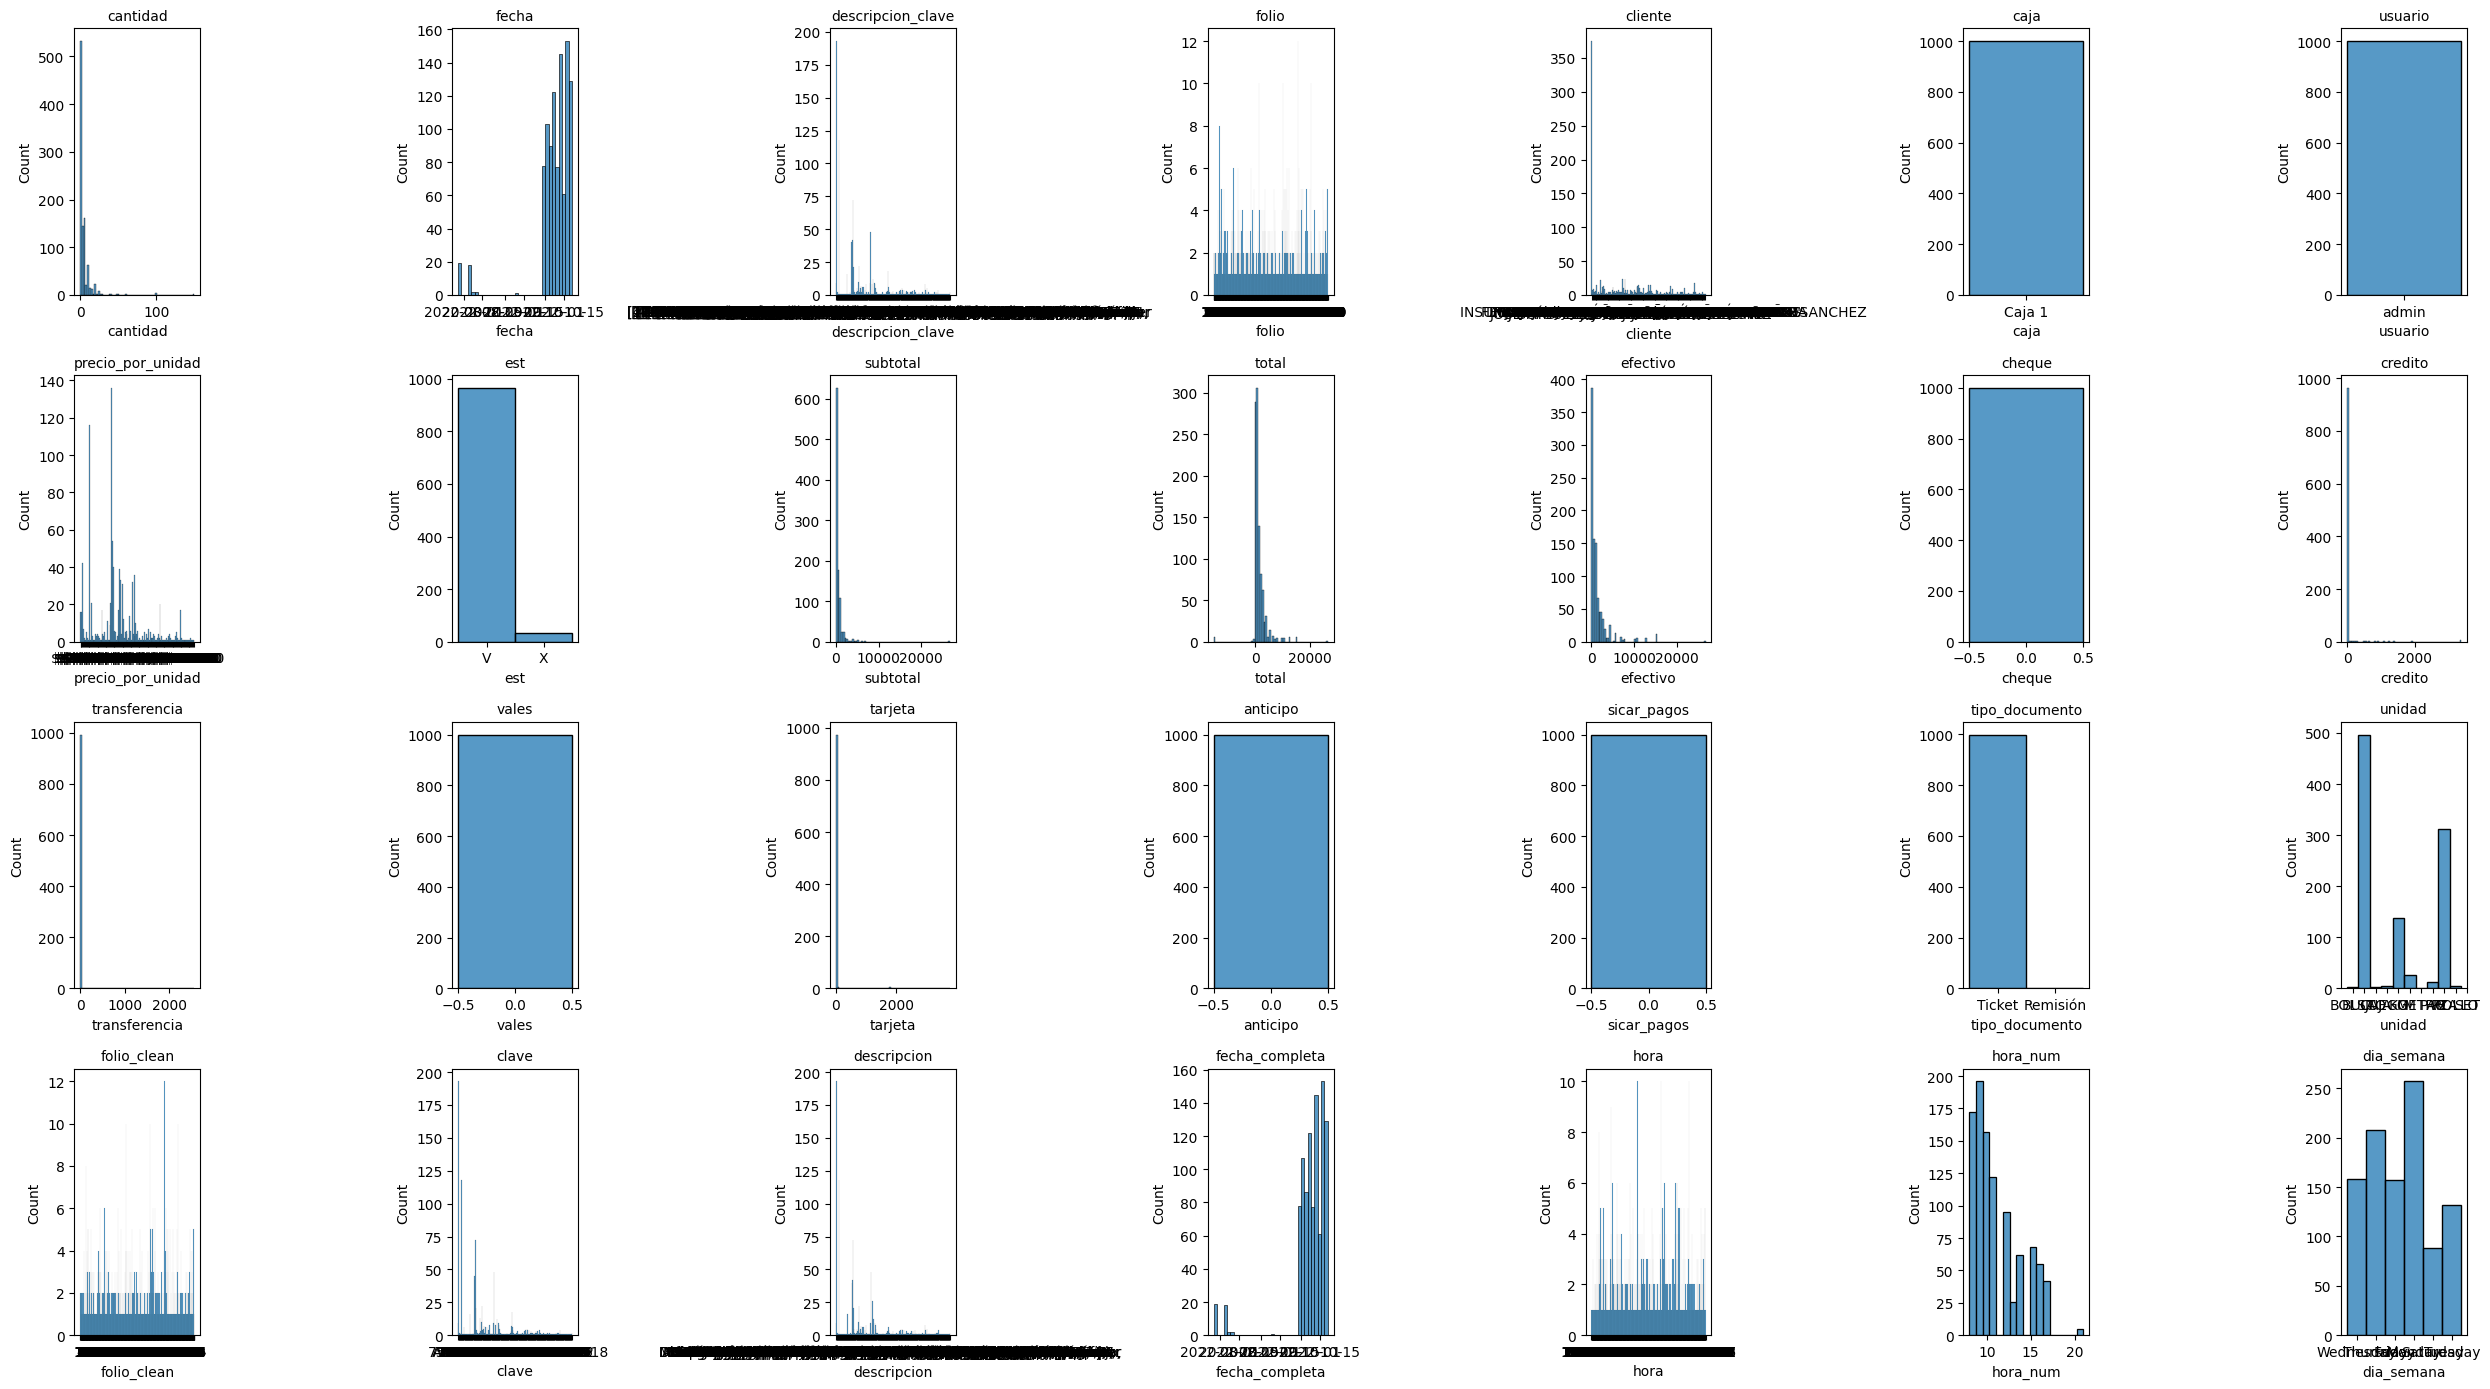

In [ ]:
fig, axes = plt.subplots(nrows=4, ncols=7, figsize=(25, 14), sharey=False)
axes = axes.flatten()

for i, column in enumerate(df_master.columns[:28]):
    sns.histplot(data=df_master.head(1000), x=column, ax=axes[i], kde=False)
    axes[i].set_title(column, fontsize=10)

plt.tight_layout()
plt.show()

In [14]:
df_numerico = df_master.select_dtypes(include=['number'])

In [17]:
matriz_correlacion = df_numerico.corr(method='pearson').abs()

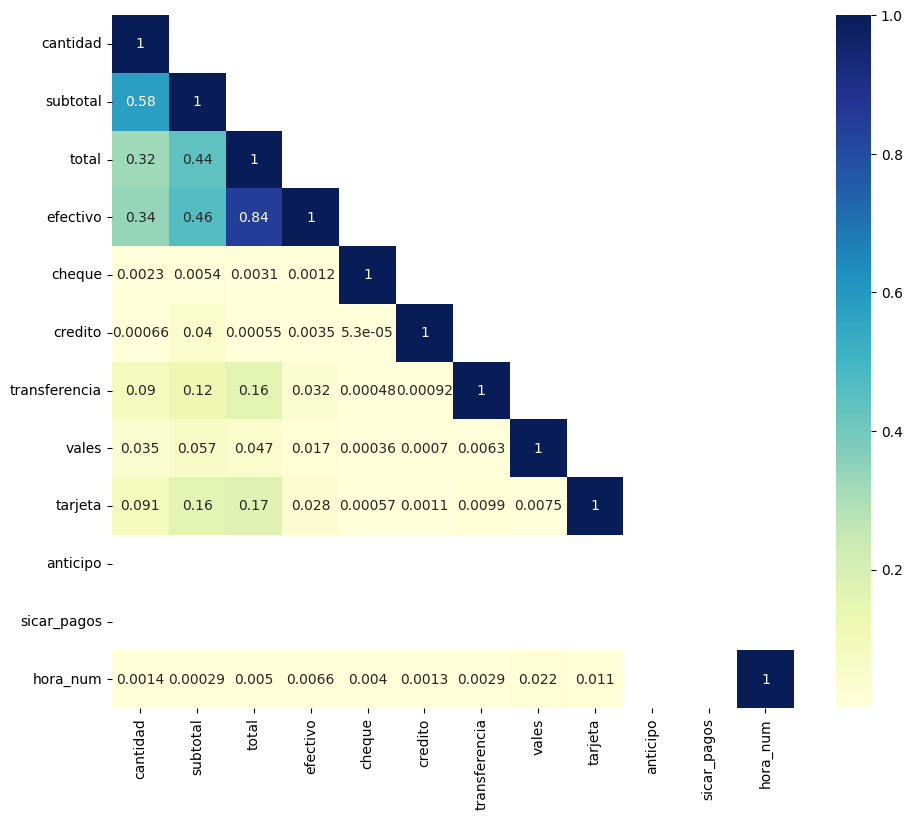

In [18]:
plt.figure(figsize=(11,9))
df_lt=matriz_correlacion.where(np.tril(np.ones(matriz_correlacion.shape)).astype(bool))
hmaps=sns.heatmap(df_lt,cmap="YlGnBu",annot=True)

<Axes: xlabel='dia_semana', ylabel='Count'>

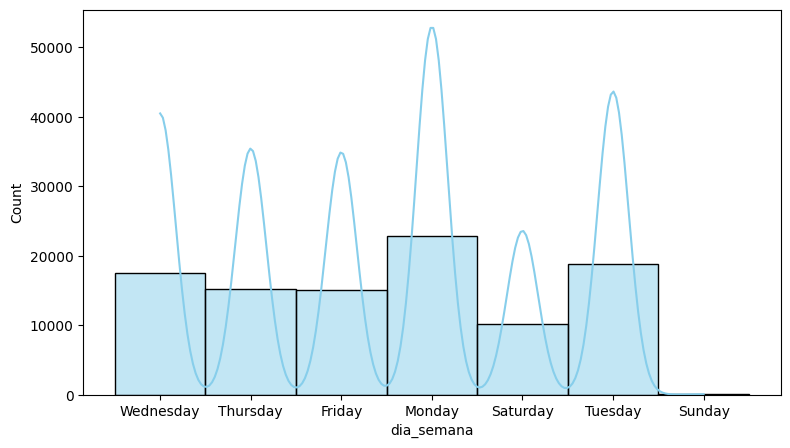

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=df_master,x='dia_semana',kde=True,bins=30,color='skyblue',ax=ax)


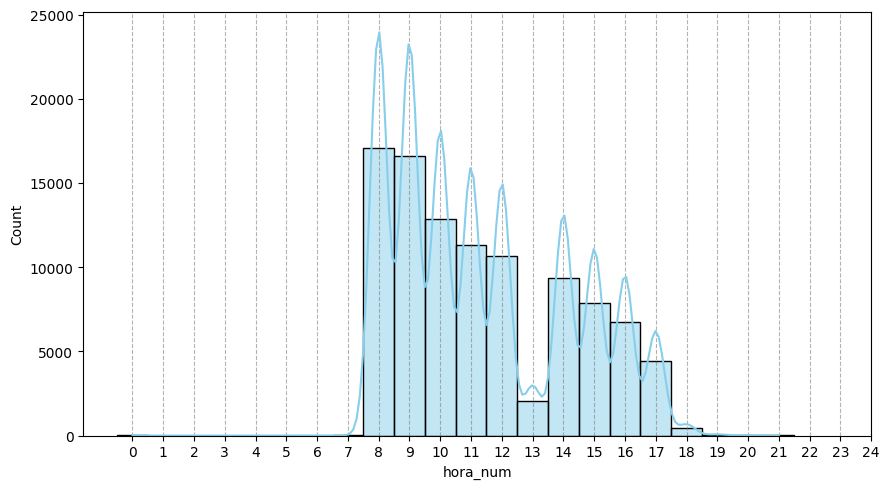

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=df_master,x='hora_num',kde=True,bins=30,discrete=True,color='skyblue',ax=ax)
ax.set_xticks(range(0, 25, 1))
ax.grid(True, axis="x", linestyle="--", alpha=0.6, color="gray")
plt.tight_layout()
plt.show()

<Axes: xlabel='unidad', ylabel='Count'>

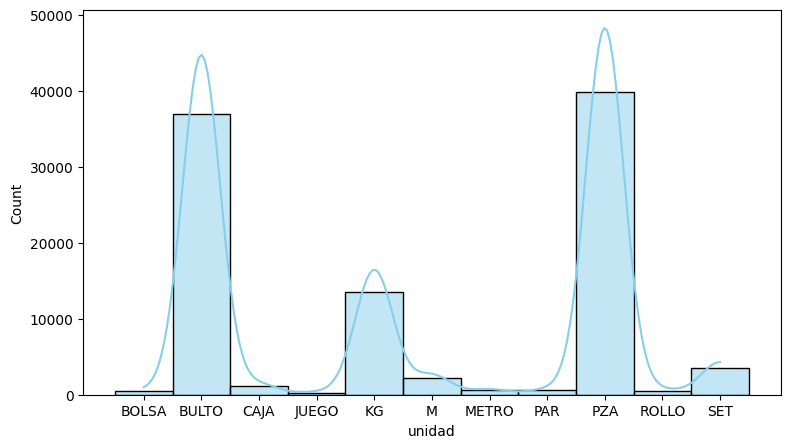

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=df_master,x='unidad',kde=True,bins=30,color='skyblue',ax=ax)


<Axes: xlabel='fecha_completa', ylabel='Count'>

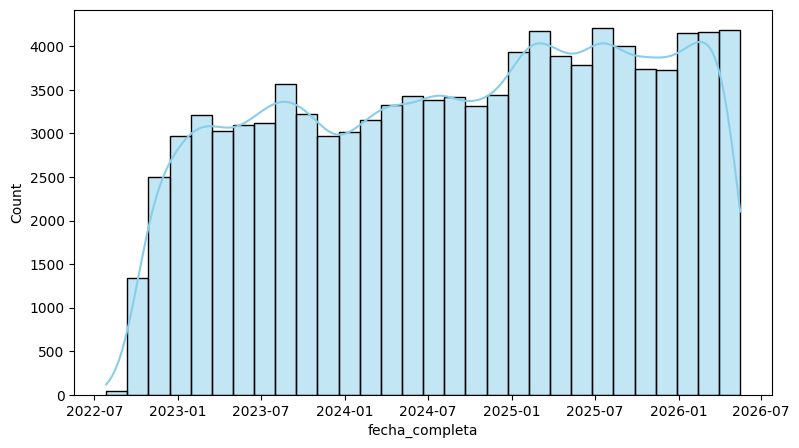

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=df_master,x='fecha_completa',kde=True,bins=30,color='skyblue',ax=ax)


<Axes: xlabel='est', ylabel='Count'>

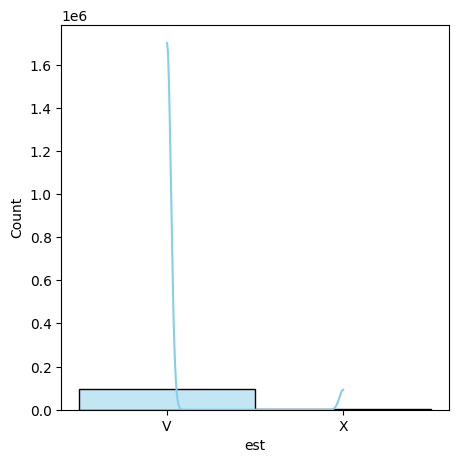

In [26]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.histplot(data=df_master,x='est',kde=True,bins=30,color='skyblue',ax=ax)


<Axes: xlabel='usuario', ylabel='Count'>

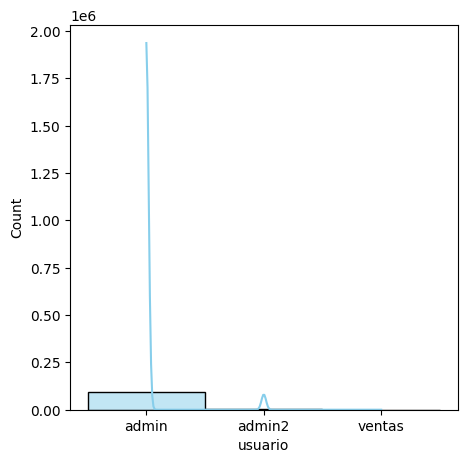

In [27]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.histplot(data=df_master,x='usuario',kde=True,bins=30,color='skyblue',ax=ax)


In [28]:
df_tickets_unique = df_master.query("est == 'V'").drop_duplicates(subset='id_ticket').copy()

In [29]:
top_20_clientes = (df_tickets_unique).groupby('cliente')['total'].sum().sort_values(ascending=False).head(20)

In [30]:
print(top_20_clientes)

cliente
Público en General                   7751287.50
BLOQUERA GIL                         1469883.00
MATERIALES JUAN UGALDE               1178484.57
GERARDO DEL LLANO                     780605.00
ORELLANA                              777999.00
JOHN SULLIVAN                         670113.00
JOSÉ VILLEGAS                         607129.50
DRA CECILIA LÓPEZ                     566177.00
MARCOS LINO ESTRADA                   502389.00
CHRISTEL BLOMQVIST                    433004.50
PEDRO OLVERA HIGUERA                  386989.00
ARQ GEORGINA ARIZA                    374058.00
JULIO MATEHUALA ORDUÑA                373650.00
JOSE LUIS LEAL LUNA                   364771.00
EZEQUIEL CAMPOS MARTINEZ              356251.00
JOSE FRANCISCO CABALLERO LUGO         351980.50
JUAN ANTONIO CASTELLANOS              330041.20
MARIA DE LA LUZ RODRIGUEZ HERRERA     321775.00
ING SALVADOR URBIOLA                  318145.00
CLARA ALVA                            287162.00
Name: total, dtype: float64


In [31]:
df_top_20_completo = df_tickets_unique[df_tickets_unique['cliente'].isin(top_20_clientes.index)]

In [32]:
fig = px.box(
    df_top_20_completo,
    x="cliente",
    y="total",
    color="cliente", 
    color_discrete_sequence=px.colors.sequential.Blues_r,
    title="Distribución de Tickets de Compra - Top 20 Clientes VIP",
    labels={
        "cliente": "ID del Cliente",
        "total": "Monto por Transacción",
    },
)
fig.update_layout(
    xaxis_tickangle=45,  
    width=1100,  
    height=500,  
    showlegend=False,
    template="plotly_dark",
)
fig.update_xaxes(categoryorder="array", categoryarray=top_20_clientes.index)
fig.show()


In [ ]:
df_master['año'] = pd.to_datetime(df_master['fecha']).dt.year

In [ ]:
df_master['mes'] = pd.to_datetime(df_master['fecha']).dt.month

In [62]:
df_filtrado = df_master[(df_master['est'] == 'V') & (df_master['año'].notna())].copy()

In [50]:
df_ventas_unicas = df_filtrado.drop_duplicates(subset=['id_ticket'])

OJO PARA HACER LAS SUMAS DE VENTAS TOTALES, LA COLUMNA EST SIGNIFICA ESTATUS V QUIERE DECIR VALIDADO Y X CANCELADO, ADEMAS CONSIDERAR QUE SE PUEDE TRABAJAR CON LOS SUBTOTALES O EN SU DEFECTO CON EL TOTAL REALIZANDO
UN DROPDUPICATES PORQUE SE REPITE EL TOTAL EN UN MISMO TICKET CON DIFERENTES PORDUCTOS

CONSIDERAR LA DIFERENCIA DE 240 YA QUE EN SICAR LA REPORTA APARTE PARA QUE EL TOTAL COINCIDA CON EL DE SICAR 
ADEMAS EN EL DESGLOSE DE SICAR POR EFECTIVO, TARJETA, CHEQUE, ETC. SICAR CONSIDERA TODAS LAS VENTAS AUNQUE SE HAYAN CANCELADO 

In [53]:
ventas_totales_por_anio = (
    df_filtrado.groupby('año')['subtotal']
    .sum()
    .reset_index()
    .sort_values(by='año', ascending=True)
)
ventas_totales_por_anio.columns = ['año', 'ventas_totales']
print(ventas_totales_por_anio)

    año  ventas_totales
0  2022      2895133.75
1  2023     14831101.63
2  2024     13407689.92
3  2025     14760204.57
4  2026      6022589.18


In [51]:
ventas_totales_por_anio = (
    df_ventas_unicas.groupby('año')['total']
    .sum()
    .reset_index()
    .sort_values(by='año', ascending=True)
)
ventas_totales_por_anio.columns = ['año', 'ventas_totales']
print(ventas_totales_por_anio)

    año  ventas_totales
0  2022      2895133.75
1  2023     14831101.63
2  2024     13407689.92
3  2025     14760204.57
4  2026      6022589.18


In [41]:
df_filtrado_ventas_ingresos_totales = df_master[df_master['est'] == 'V'].copy()
top_10_ingresos = (
    df_filtrado_ventas_ingresos_totales.groupby(['clave', 'descripcion'])['subtotal']
    .sum()
    .reset_index(name='Ingresos_Totales')
    .sort_values(by='Ingresos_Totales', ascending=False)
    .head(10)
)
top_10_ingresos.reset_index(drop=True, inplace=True)

print("--- TOP 10 PRODUCTOS POR INGRESOS ---")
print(top_10_ingresos)

--- TOP 10 PRODUCTOS POR INGRESOS ---
   clave                          descripcion  Ingresos_Totales
0   0054   CEMENTO GRIS CRUZ AZUL CPC 30 50KG        8202427.40
1  02638                      VARILLA R42 3/8        7199253.46
2   0054        CEMENTO GRIS CRUZ AZUL CPC 30        6740348.50
3    002                              CALIDRA        3437475.00
4   0055        CEMENTO GRIS MOCTEZUMA CPC 30        3110661.50
5   0064              MORTERO CRUZ AZUL 50 kg        2000227.88
6   0055  CEMENTO GRIS MOCTEZUMA 25 KG CPC 30        1238099.00
7   0050  CEMENTO GRIS CRUZ AZUL CPC 30 25 KG        1159203.22
8   0064                    MORTERO CRUZ AZUL        1104143.00
9  02520          ARMEX 15 X 20 - 4 (10 X 15)        1080580.50


In [42]:
top_10_volumen = (
    df_filtrado_ventas_ingresos_totales.groupby(['clave', 'descripcion'])['cantidad']
    .sum()
    .reset_index(name='Unidades_Vendidas')
    .sort_values(by='Unidades_Vendidas', ascending=False)
    .head(10)
)

top_10_volumen.reset_index(drop=True, inplace=True)

print("\n--- TOP 10 PRODUCTOS POR VOLUMEN DE UNIDADES ---")
print(top_10_volumen)


--- TOP 10 PRODUCTOS POR VOLUMEN DE UNIDADES ---
   clave                                      descripcion  Unidades_Vendidas
0  02638                                  VARILLA R42 3/8         52697.0000
1    002                                          CALIDRA         37680.0000
2   0054               CEMENTO GRIS CRUZ AZUL CPC 30 50KG         35915.0000
3   0054                    CEMENTO GRIS CRUZ AZUL CPC 30         31244.0000
4   0055                    CEMENTO GRIS MOCTEZUMA CPC 30         15942.0000
5  44457       Kilo de alambre recocido calibre 15, Fiero         14374.3465
6  02202                                  ESTRIBO 10 X 15         13500.2953
7  02204                                  ESTRIBO 10 X 25         12584.3310
8   0055              CEMENTO GRIS MOCTEZUMA 25 KG CPC 30         10900.0000
9  44457  ALRE-160 Kilo de alambre recocido calibre 15 en         10497.4804


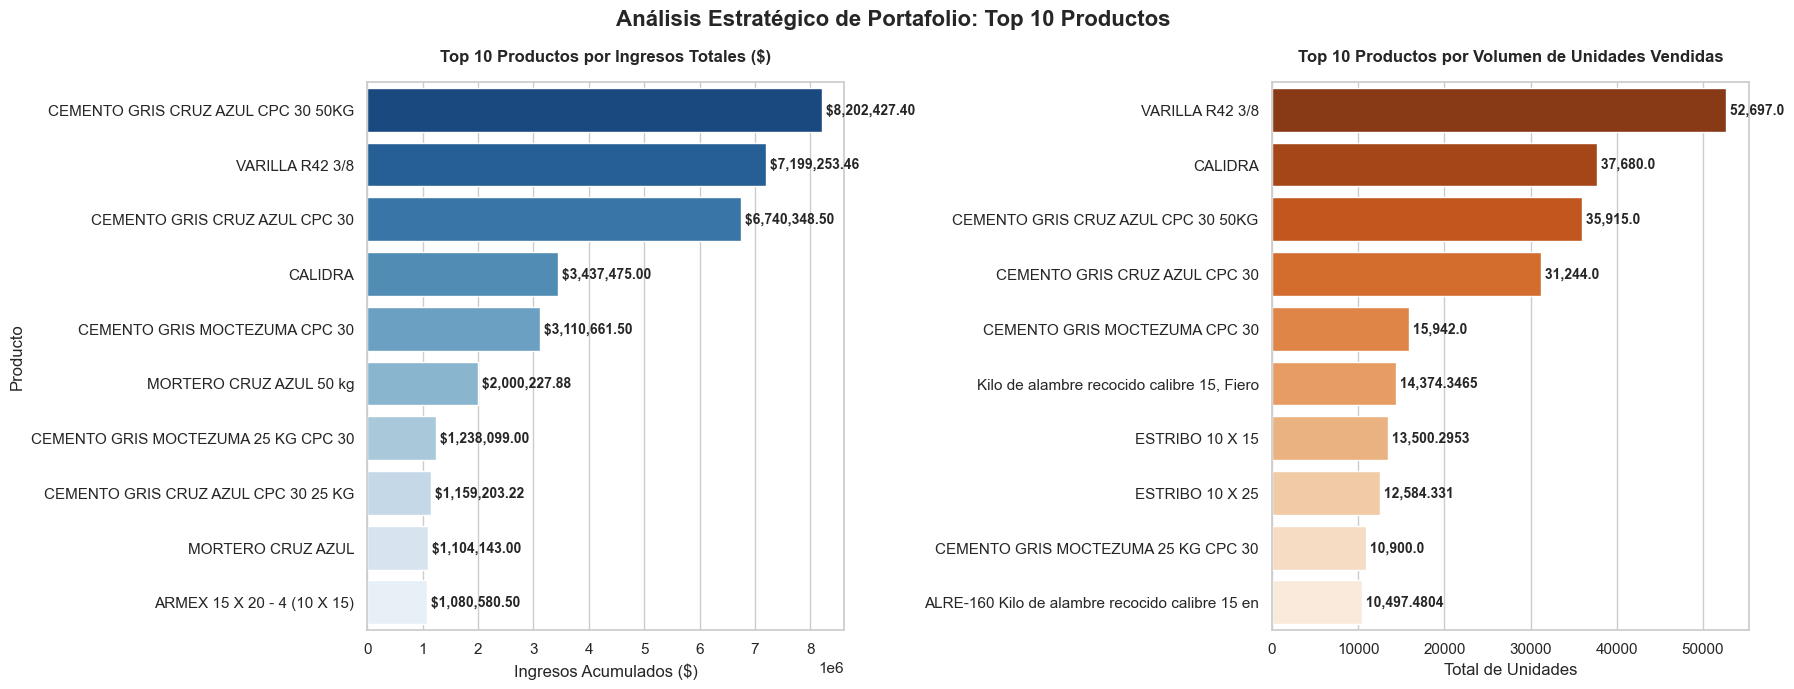

In [44]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'figure.titlesize': 16})

# 2. Inicializar la figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=False)
fig.suptitle('Análisis Estratégico de Portafolio: Top 10 Productos', weight='bold', y=0.98)

sns.barplot(
    x='Ingresos_Totales', 
    y='descripcion', 
    data=top_10_ingresos, 
    ax=axes[0], 
    palette='Blues_r', 
    hue='descripcion',
    legend=False
)
axes[0].set_title('Top 10 Productos por Ingresos Totales ($)', weight='bold', pad=15)
axes[0].set_xlabel('Ingresos Acumulados ($)')
axes[0].set_ylabel('Producto')

for index, value in enumerate(top_10_ingresos['Ingresos_Totales']):
    axes[0].text(value, index, f' ${value:,.2f}', va='center', ha='left', fontsize=10, weight='semibold')


sns.barplot(
    x='Unidades_Vendidas', 
    y='descripcion', 
    data=top_10_volumen, 
    ax=axes[1], 
    palette='Oranges_r', 
    hue='descripcion',
    legend=False
)
axes[1].set_title('Top 10 Productos por Volumen de Unidades Vendidas', weight='bold', pad=15)
axes[1].set_xlabel('Total de Unidades')
axes[1].set_ylabel('')

for index, value in enumerate(top_10_volumen['Unidades_Vendidas']):
    axes[1].text(value, index, f' {value:,}', va='center', ha='left', fontsize=10, weight='semibold')

plt.tight_layout()

plt.show()

In [ ]:
variabilidad_precios = (
    df_filtrado.groupby(['id_producto', 'nombre_producto'])['precio por unidad']
    .agg(['min', 'max', 'mean', 'std'])
    .reset_index()
)

In [55]:
ventas_por_anio = (
    df_filtrado.groupby('año')['subtotal']
    .sum()
    .reset_index()
)

In [56]:
ventas_por_anio = ventas_por_anio.sort_values(by='año')

/var/folders/x9/t_bd_v1d7m56wm87y_z_vqgh0000gn/T/ipykernel_28038/633758934.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


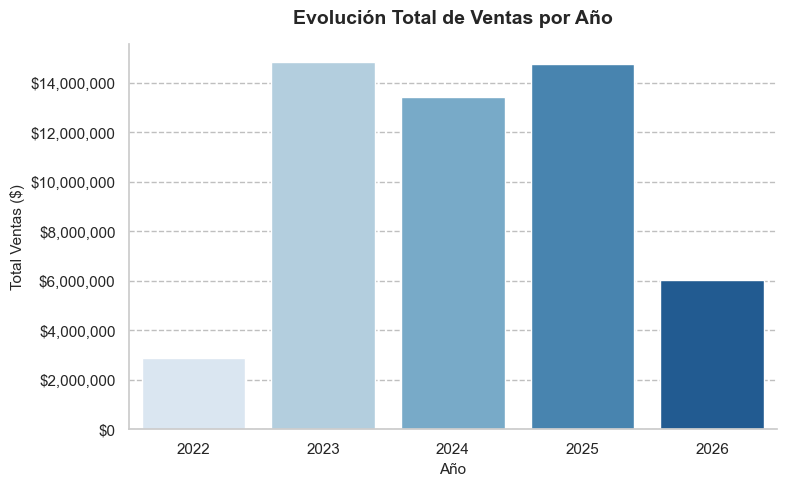

In [57]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=ventas_por_anio, 
    x='año',        # El tiempo en el eje X
    y='subtotal',    # El dinero en el eje Y
    ax=ax, 
    palette='Blues'  # Paleta de colores azules
)

ax.set_title('Evolución Total de Ventas por Año', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Total Ventas ($)', fontsize=11)

ax.yaxis.set_major_formatter('${x:,.0f}')

ax.grid(True, axis="y", linestyle="--", alpha=0.5, color="gray")

sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

In [98]:
top_5 = top_10_ingresos['descripcion'].head(5).tolist()

In [101]:
df_top5 = df_master[(df_master['est'] == 'V') & (df_master['descripcion'].isin(top_5))].copy()

In [102]:
df_top5['periodo'] = pd.to_datetime(df_top5['fecha']).dt.to_period('M').astype(str)

In [110]:
evolucion = (
    df_top5.groupby(['periodo', 'descripcion'])['subtotal']
    .sum()
    .reset_index()
)

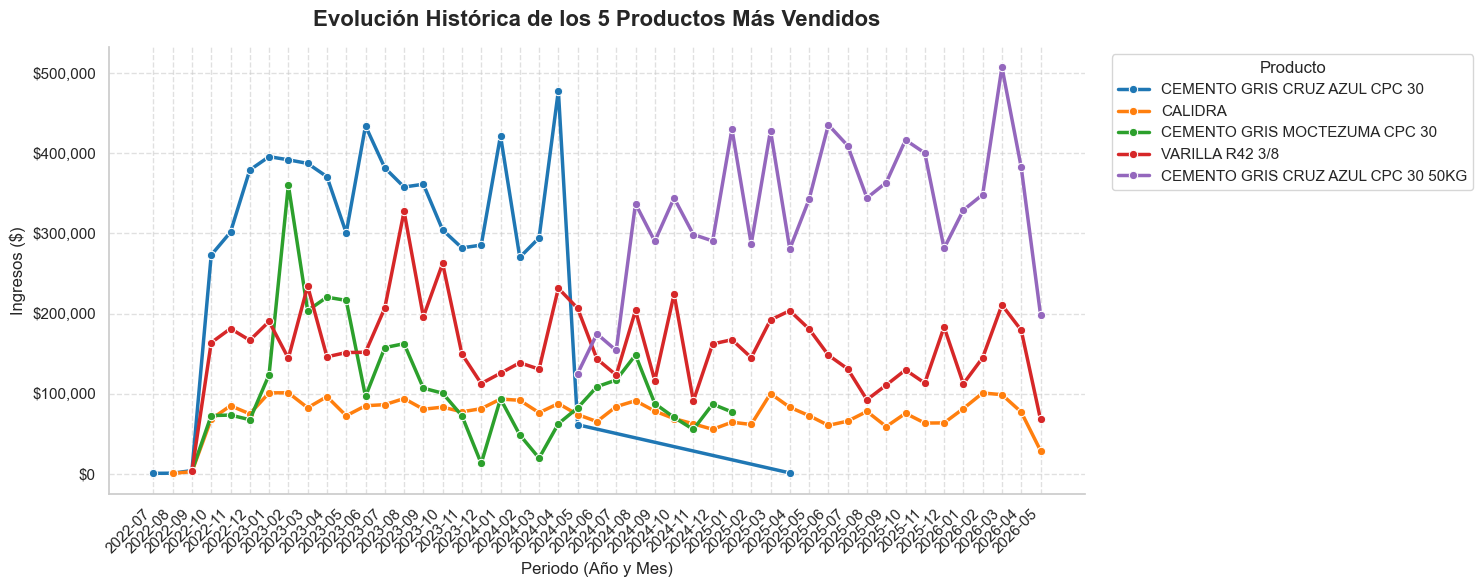

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))

sns.lineplot(
    data=evolucion,
    x='periodo',
    y='subtotal',
    hue='descripcion',
    marker='o',
    linewidth=2.5,
    palette='tab10',
    ax=ax
)

ax.set_title('Evolución Histórica de los 5 Productos Más Vendidos', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Periodo (Año y Mes)', fontsize=12)
ax.set_ylabel('Ingresos ($)', fontsize=12)

plt.xticks(rotation=45, ha='right')

ax.yaxis.set_major_formatter('${x:,.0f}')

ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(title='Producto', bbox_to_anchor=(1.02, 1), loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()

In [105]:
top_5_volumen = top_10_volumen['descripcion'].head(5).tolist()

In [106]:
df_top5_volumen = df_master[(df_master['est'] == 'V') & (df_master['descripcion'].isin(top_5_volumen))].copy()

In [107]:
df_top5_volumen['periodo'] = pd.to_datetime(df_top5['fecha']).dt.to_period('M').astype(str)

In [111]:
evolucion_volumen = (
    df_top5_volumen.groupby(['periodo', 'descripcion'])['cantidad']
    .sum()
    .reset_index()
)

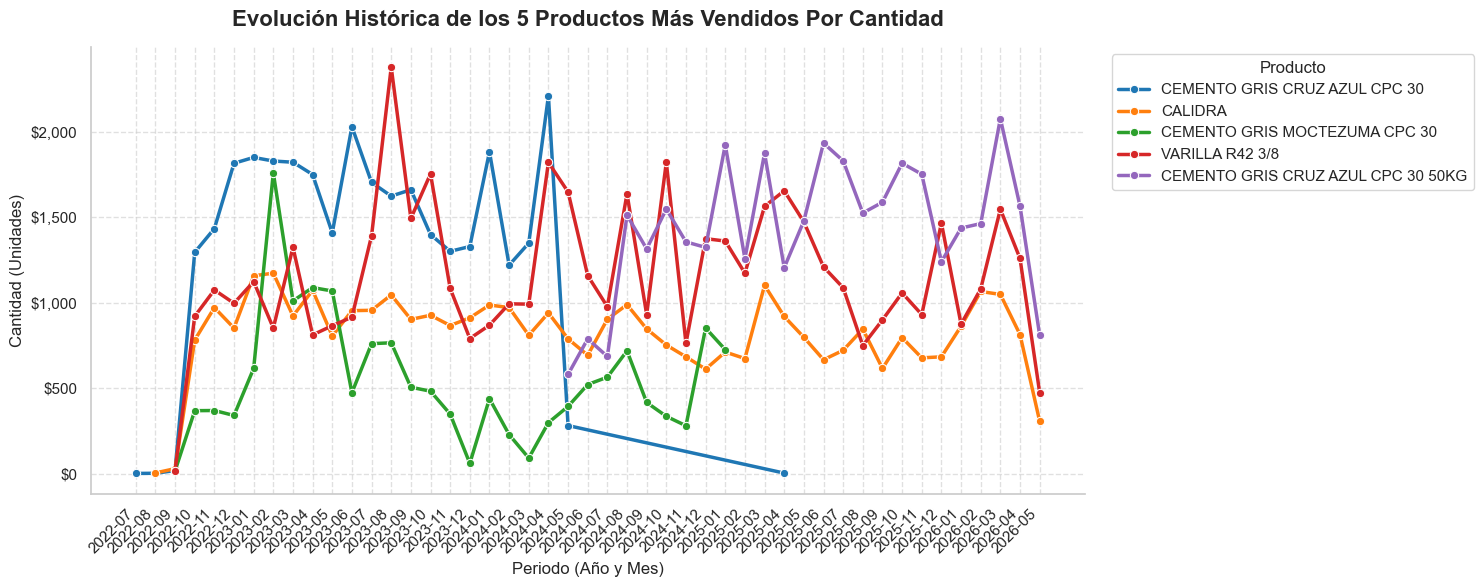

In [113]:
fig, ax = plt.subplots(figsize=(15, 6))

sns.lineplot(
    data=evolucion_volumen,
    x='periodo',
    y='cantidad',
    hue='descripcion',
    marker='o',
    linewidth=2.5,
    palette='tab10',
    ax=ax
)

ax.set_title('Evolución Histórica de los 5 Productos Más Vendidos Por Cantidad', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Periodo (Año y Mes)', fontsize=12)
ax.set_ylabel('Cantidad (Unidades)', fontsize=12)

plt.xticks(rotation=45, ha='right')

ax.yaxis.set_major_formatter('${x:,.0f}')

ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(title='Producto', bbox_to_anchor=(1.02, 1), loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()

In [121]:
ventas_mensuales_totales = (
    df_filtrado.groupby(['año', 'mes'])['subtotal']
    .sum()
    .reset_index()
)

In [122]:
ventas_mensuales_totales['año'] = ventas_mensuales_totales['año'].astype(str)

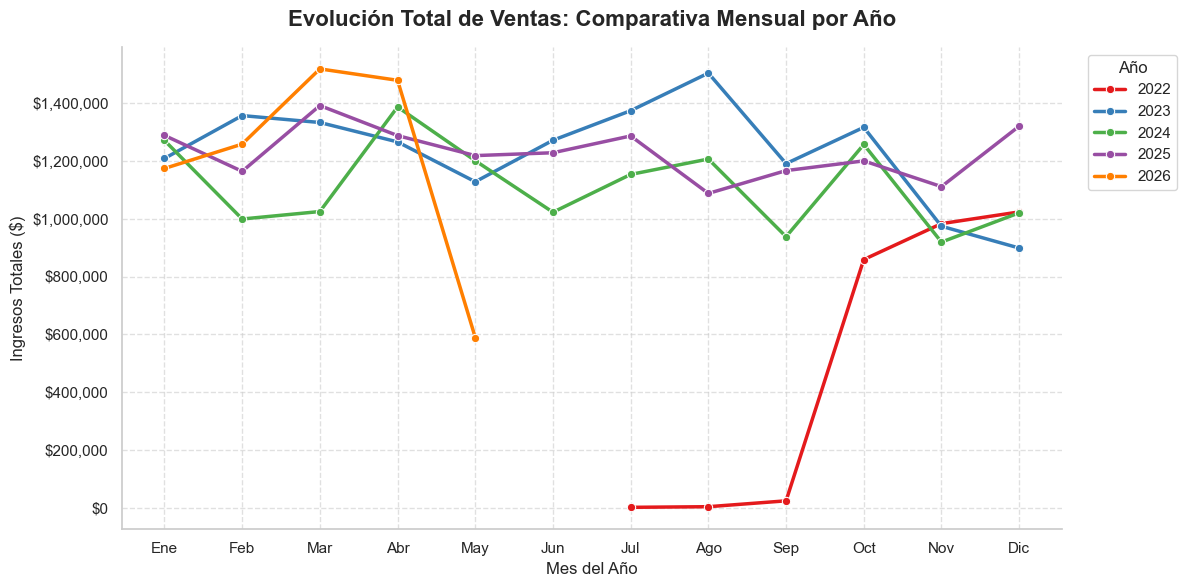

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=ventas_mensuales_totales,
    x='mes',
    y='subtotal',
    hue='año',         
    marker='o',          
    linewidth=2.5,      
    palette='Set1',      
    ax=ax
)

ax.set_title('Evolución Total de Ventas: Comparativa Mensual por Año', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Mes del Año', fontsize=12)
ax.set_ylabel('Ingresos Totales ($)', fontsize=12)

ax.set_xticks(range(1, 13))

nombres_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
ax.set_xticklabels(nombres_meses)

ax.yaxis.set_major_formatter('${x:,.0f}')

ax.grid(True, linestyle='--', alpha=0.6)

ax.legend(title='Año', bbox_to_anchor=(1.02, 1), loc='upper left')

sns.despine()

plt.tight_layout()
plt.show()

In [126]:
from itertools import combinations
from collections import Counter

In [128]:
df_validos = df_master[df_master['est'] == 'V'].copy()

In [129]:
df_tickets = df_validos.drop_duplicates(subset=['id_ticket', 'descripcion'])

In [130]:
conteo_items = df_tickets['id_ticket'].value_counts()
tickets_multiples = conteo_items[conteo_items > 1].index
df_multiples = df_tickets[df_tickets['id_ticket'].isin(tickets_multiples)]

In [131]:
agrupado = df_multiples.groupby('id_ticket')['descripcion'].apply(list)

In [132]:
contador_pares = Counter()

for productos in agrupado:
    productos_ordenados = sorted(productos)
    for par in combinations(productos_ordenados, 2):
        contador_pares[par] += 1

In [133]:
df_pares = pd.DataFrame(contador_pares.items(), columns=['Par_de_Productos', 'Veces_Comprados_Juntos'])

In [134]:
df_pares[['Producto_A', 'Producto_B']] = pd.DataFrame(df_pares['Par_de_Productos'].tolist(), index=df_pares.index)

In [135]:
df_pares_top = df_pares[['Producto_A', 'Producto_B', 'Veces_Comprados_Juntos']].sort_values(by='Veces_Comprados_Juntos', ascending=False)

In [141]:
df_pares_top.head(20)

,Producto_A,Producto_B,Veces_Comprados_Juntos
4,CALIDRA,CEMENTO GRIS CRUZ AZUL CPC 30,1746
12410,CALIDRA,CEMENTO GRIS CRUZ AZUL CPC 30 50KG,1645
46,CALIDRA,CEMENTO GRIS MOCTEZUMA CPC 30,914
13881,CEMENTO GRIS CRUZ AZUL CPC 30 50KG,MORTERO CRUZ AZUL 50 kg,719
12413,CEMENTO GRIS CRUZ AZUL CPC 30 50KG,VARILLA R42 3/8,681
226,CALIDRA,VARILLA R42 3/8,619
26,ARMEX 15 X 20 - 4 (10 X 15),CALIDRA,608
20259,CALIDRA,CEMENTO GRIS MOCTEZUMA 25 KG CPC 30,597
11,CEMENTO GRIS CRUZ AZUL CPC 30,VARILLA R42 3/8,587
14,"Kilo de alambre recocido calibre 15, Fiero",VARILLA R42 3/8,560


In [144]:
producto_buscado = "CEMENTO GRIS CRUZ AZUL CPC 30"
filtro = (df_master['est'] == 'V') & (df_master['descripcion'] == producto_buscado)
ventas_producto = df_master[filtro]
ultima_fecha = ventas_producto['fecha'].max()
print(f"La última venta de '{producto_buscado}' fue el: {ultima_fecha}")

La última venta de 'CEMENTO GRIS CRUZ AZUL CPC 30' fue el: 2025-04-09 11:09:37


In [147]:
df_master.to_parquet('rep_ventas_general_limpio.parquet', compression='snappy')